# **ACT4 – Multi-Variant Text Analysis and Generation (BERT, GPT, and GANs)**
Submitted by:

Sibayan, Gian Eugene

CSS182-4 CM1

This notebook builds and compares three different NLP models using the IMDB movie review dataset: BERT for sentiment classification, GPT-2 for text generation, and a Text-GAN for adversarial text generation. Each model is trained on the same data splits, then evaluated using shared metrics like F1-score, perplexity, BLEU, and ROUGE. The goal is to compare how these three approaches understand and generate text differently, and to explain the tradeoffs between them.

# Preparing Libraries and Dataset

## Dataset Description

IMDB Dataset of 50K Movie Reviews — a binary sentiment classification dataset containing 50,000 movie reviews labeled as positive or negative, with 25,000 samples for training and 25,000 for testing.

Source: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews


## Check GPU And Install Required Libraries

In [19]:
# checks which gpu colab has assigned to this runtime
# confirms t4 is active before any training begins
!nvidia-smi

# installs hugging face libraries needed for bert, gpt, and evaluation metrics
# rouge and sacrebleu are used later for generative quality scoring
!pip install -q transformers datasets evaluate rouge_score sacrebleu accelerate

Tue Jul  7 07:02:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P0             29W /   70W |     577MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Import Core Libraries

In [20]:
# imports libraries used across data handling and model training
# torch backend is used since transformers integrates with it directly
import torch
import numpy as np
import pandas as pd

# confirms gpu is visible to torch before proceeding
# prevents wasted time discovering cpu-only training later
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

True Tesla T4


Setup Seeding

In [21]:
# defines a function that seeds all random number generators used in this notebook
# ensures reruns produce identical results instead of shifting each time
import random

def set_all_seeds(seed=48):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# calls the seeding function immediately after defining it
# locks in reproducibility from the very start of the notebook
set_all_seeds(48)

## Mount Drive And Load Dataset

In [22]:
# mounts google drive to access the imdb csv file
# authorization prompt appears in the cell output
from google.colab import drive
drive.mount('/content/drive')

# loads the imdb csv and previews its structure
# confirms both columns exist: review and sentiment
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/IMDB Dataset.csv")

print("\nClass distribution:")
print(df['sentiment'].value_counts())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Encode Sentiment Labels

In [23]:
# encodes sentiment text labels into numeric binary values
# label column used for classification and gan training targets
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1})

# displays class distribution after encoding
# full kaggle imdb set contains 50000 rows total
print(df['label'].value_counts())
df.head()

label
1    25000
0    25000
Name: count, dtype: int64


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


## Subsample Dataset For Training Speed

In [24]:
# subsamples dataset to reduce training time across three model variants
# stratify preserves the original 50/50 class balance in the smaller set
from sklearn.model_selection import train_test_split

df_small, _ = train_test_split(df, train_size=3000, stratify=df['label'], random_state=42)

# displays subsample size and class balance
# 3000 rows balances signal quality against compute time
print(df_small.shape)
print(df_small['label'].value_counts())

(3000, 3)
label
1    1500
0    1500
Name: count, dtype: int64


## Split Data Into Train Validation Test Sets

In [25]:
# splits subsample into train, validation, and test sets
# shared across bert, gpt, and gan so all three use identical data
train_df, temp_df = train_test_split(df_small, test_size=0.2, stratify=df_small['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# displays final split sizes and class balance
# these three splits are the ones bert, gpt, and gan all read from
print(f"train: {train_df.shape}, val: {val_df.shape}, test: {test_df.shape}")
print(train_df['label'].value_counts())

train: (2400, 3), val: (300, 3), test: (300, 3)
label
1    1200
0    1200
Name: count, dtype: int64


# Variant 1: BERT (Bidirectional Encoder Representations from Transformers)

## Load BERT Tokenizer

In [34]:
# loads the pretrained bert tokenizer matching bert-base-uncased
# tokenizer converts raw review text into token ids the model understands
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# confirms tokenizer loaded correctly on a sample review
# shows token ids and their decoded form side by side
sample = tokenizer(train_df['review'].iloc[0], truncation=True, max_length=256)
print(sample['input_ids'][:20])
print(tokenizer.decode(sample['input_ids'][:20]))

[101, 1026, 7987, 1013, 1028, 1026, 7987, 1013, 1028, 2821, 2026, 2773, 999, 999, 1045, 2031, 2196, 2464, 1037, 2143]
[CLS] < br / > < br / > oh my word!! i have never seen a film


## Convert Splits Into Hugging Face Dataset Format

In [35]:
# converts pandas dataframes into hugging face dataset objects
# dataset format is required for the tokenizer map function and trainer api
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df[['review', 'label']].reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df[['review', 'label']].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[['review', 'label']].reset_index(drop=True))

# displays one converted dataset to confirm structure
# confirms review and label columns carried over correctly
print(train_ds)

Dataset({
    features: ['review', 'label'],
    num_rows: 2400
})


## Tokenize All Three Splits

In [36]:
# defines tokenization function applied across all splits
# truncation and fixed max_length keep sequence sizes consistent
def tokenize_fn(batch):
    return tokenizer(batch['review'], truncation=True, padding='max_length', max_length=256)

# applies tokenization to train, validation, and test sets
# batched processing speeds up tokenization across all rows
train_tok = train_ds.map(tokenize_fn, batched=True)
val_tok = val_ds.map(tokenize_fn, batched=True)
test_tok = test_ds.map(tokenize_fn, batched=True)

# displays tokenized train set structure
# confirms input_ids and attention_mask columns were added
print(train_tok)

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Dataset({
    features: ['review', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2400
})


## Load BERT Classification Model

In [37]:
# loads pretrained bert-base-uncased with a classification head attached
# num_labels set to 2 for binary sentiment classification
from transformers import AutoModelForSequenceClassification

set_all_seeds(48)

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# moves model to gpu if available
# ensures training runs on t4 instead of falling back to cpu
model = model.to("cuda" if torch.cuda.is_available() else "cpu")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Define Evaluation Metrics

In [38]:
# defines function computing precision, recall, and f1 during training
# metrics match the primary metric required for the bert variant
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

## Set Training Arguments

In [39]:
# defines training configuration for the bert finetuning run
# small epoch count and batch size chosen to fit within colab time limits
from transformers import TrainingArguments

training_args = TrainingArguments(
    seed=48,
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

## Initialize And Run Trainer

In [40]:
# initializes trainer with model, data, and metric function
# handles the full training and evaluation loop automatically
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics
)

# starts finetuning on the training set
# validation metrics print after each epoch
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.324823,0.876667,0.874172,0.880000,0.877076
2,No log,0.350044,0.893333,0.883117,0.906667,0.894737
3,No log,0.400057,0.890000,0.892617,0.886667,0.889632


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=450, training_loss=0.24975297715928818, metrics={'train_runtime': 412.0018, 'train_samples_per_second': 17.476, 'train_steps_per_second': 1.092, 'total_flos': 947199799296000.0, 'train_loss': 0.24975297715928818, 'epoch': 3.0})

Validation loss went up every epoch (0.325, 0.350, 0.400). But accuracy and F1 actually peaked at epoch 2, then dropped a bit by epoch 3. This means the model was still improving up to epoch 2, then started overfitting after that. It was learning the training data too closely instead of getting better at new data. Mini-batches of size 16 were used instead of the whole dataset at once, since smaller batches update the model more often and fit better in GPU memory.

## Evaluate BERT On Test Set

In [41]:
# runs trained model against the held-out test set
# test set was untouched during training and validation
test_results = trainer.evaluate(test_tok)

# displays final test metrics for the bert variant
# these are the numbers that go into the comparison matrix
print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
No log,0.237222,3,0.920000,0.888889,0.960000,0.923077


{'eval_loss': 0.23722165822982788, 'eval_accuracy': 0.92, 'eval_precision': 0.8888888888888888, 'eval_recall': 0.96, 'eval_f1': 0.9230769230769231}


Test performance is strong, with F1 at 0.923, accuracy at 0.920, and eval loss at 0.237, which is good given the model was finetuned on just 2,400 training examples. Recall (0.960) noticeably outpaces precision (0.889), meaning the model is catching almost all actual positive reviews but occasionally mislabels a negative review as positive, giving it a mild bias toward predicting the positive class. Given the balanced 50/50 label distribution in training, this asymmetry likely comes down to which specific examples the model found easy versus ambiguous, rather than any systematic issue with the setup. Overall, the low eval loss alongside strong F1 suggests the model generalized well to unseen data rather than simply memorizing training patterns.

## Plot Confusion Matrix

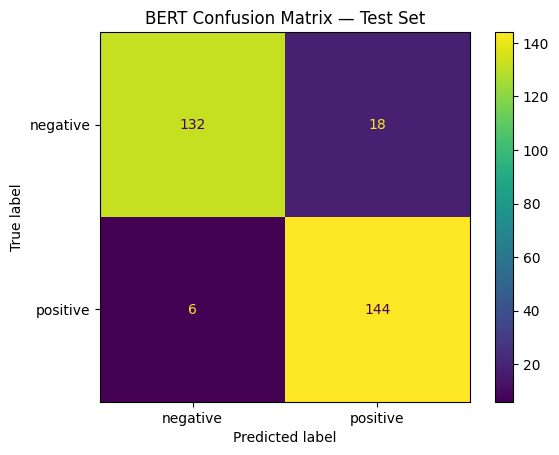

In [42]:
# generates model predictions on the held-out test set
# predictions needed to build the confusion matrix
test_preds = trainer.predict(test_tok)
pred_labels = np.argmax(test_preds.predictions, axis=-1)

# builds and displays the confusion matrix
# compares predicted labels against true test labels
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(test_df['label'], pred_labels, display_labels=['negative', 'positive'])
plt.title("BERT Confusion Matrix — Test Set")
plt.show()

Out of 150 negative reviews, 132 were correctly caught and 18 slipped through as false positives. Out of 150 positive reviews, 144 were correctly caught and only 6 were missed as false negatives. That 18-vs-6 imbalance is exactly what drove precision (0.889) below recall (0.960). The model has a slight bias toward predicting "positive," so it's more likely to mistakenly call a negative review positive than the reverse. Overall the errors are small and reasonably spread, which lines up with a solid, non-degenerate classifier. Nothing here suggests it's collapsed onto one class or memorized surface patterns.

# Variant 2: GPT (Generative Pre-trained Transformer)

## Load GPT-2 Tokenizer And Model

In [43]:
# loads pretrained distilgpt2 tokenizer and model
# distilgpt2 is lighter than full gpt-2, faster to finetune on a t4
from transformers import AutoTokenizer, AutoModelForCausalLM

gpt_tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
gpt_model = AutoModelForCausalLM.from_pretrained("distilgpt2")

# sets pad token to eos token since gpt2 has no pad token by default
# required for batching sequences of different lengths
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

# moves model to gpu if available
# ensures finetuning runs on t4 instead of cpu
gpt_model = gpt_model.to("cuda" if torch.cuda.is_available() else "cpu")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

## Tokenize Reviews For Causal Language Modeling

In [44]:
# converts train and validation splits into hugging face dataset format
# gpt-2 training only needs train and validation, test is used later for generation comparison
from datasets import Dataset

gpt_train_ds = Dataset.from_pandas(train_df[['review']].reset_index(drop=True))
gpt_val_ds = Dataset.from_pandas(val_df[['review']].reset_index(drop=True))

# defines tokenization function for causal language modeling
# truncation caps sequence length, no fixed padding since data collator handles it dynamically
def gpt_tokenize_fn(batch):
    return gpt_tokenizer(batch['review'], truncation=True, max_length=256)

# applies tokenization across train and validation sets
# removes original text column since only token ids are needed for training
gpt_train_tok = gpt_train_ds.map(gpt_tokenize_fn, batched=True, remove_columns=['review'])
gpt_val_tok = gpt_val_ds.map(gpt_tokenize_fn, batched=True, remove_columns=['review'])

# displays tokenized train set structure
# confirms input_ids and attention_mask columns are present
print(gpt_train_tok)

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 2400
})


## Set Up Data Collator For Language Modeling

In [45]:
# creates a data collator that handles dynamic padding and label shifting
# mlm=false configures it for causal language modeling instead of masked language modeling
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(tokenizer=gpt_tokenizer, mlm=False)

## Set GPT-2 Training Arguments

In [48]:
# defines training configuration for gpt-2 finetuning
# lower epoch count than bert since generative finetuning converges faster on small data
from transformers import TrainingArguments

gpt_training_args = TrainingArguments(
    seed=48,
    output_dir="./gpt_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none"
)

## Initialize And Run GPT-2 Trainer

In [49]:
# initializes trainer with gpt-2 model, tokenized data, and collator
# no compute_metrics needed here since loss and perplexity are derived directly from eval loss
from transformers import Trainer

gpt_trainer = Trainer(
    model=gpt_model,
    args=gpt_training_args,
    train_dataset=gpt_train_tok,
    eval_dataset=gpt_val_tok,
    data_collator=data_collator
)

# starts finetuning on the training set
# validation loss printed after each epoch, used later to calculate perplexity
gpt_trainer.train()

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,No log,3.847517
2,3.908823,3.839484
3,3.908823,3.839419


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=900, training_loss=3.838070610894097, metrics={'train_runtime': 403.4444, 'train_samples_per_second': 17.846, 'train_steps_per_second': 2.231, 'total_flos': 469717654044672.0, 'train_loss': 3.838070610894097, 'epoch': 3.0})

Validation loss barely changed across all three epochs (3.848, 3.839, 3.839). This means the model reached its limit almost right away instead of slowly improving. That makes sense with only 2,400 training reviews and a model that already knows English well from pretraining. Mini-batches of size 8 were used to keep memory use low on the T4 GPU while still updating the model often.

## Calculate Perplexity From Validation Loss

In [50]:
# retrieves final evaluation loss from the trainer state
# perplexity is derived directly from cross-entropy loss for causal language models
import math

eval_loss = gpt_trainer.evaluate()['eval_loss']
perplexity = math.exp(eval_loss)

# displays validation loss and corresponding perplexity
# lower perplexity indicates the model predicts held-out text more confidently
print(f"Validation loss: {eval_loss:.4f}")
print(f"Perplexity: {perplexity:.4f}")

Training Loss,Validation Loss,Epoch
3.908823,3.839419,3


Validation loss: 3.8394
Perplexity: 46.4985


## Generate Text From A Domain Prompt

In [51]:
# sets model to evaluation mode before generation
# disables dropout and other training-only behaviors
gpt_model.eval()

# defines a domain-specific prompt matching the review dataset style
# generation continues the prompt using the finetuned model
prompt = "This movie was"
input_ids = gpt_tokenizer(prompt, return_tensors="pt").input_ids.to(gpt_model.device)

# generates a continuation using sampling for more natural variation
# max_new_tokens caps output length, temperature controls randomness
output = gpt_model.generate(
    input_ids,
    max_new_tokens=60,
    do_sample=True,
    temperature=0.8,
    top_p=0.9,
    pad_token_id=gpt_tokenizer.eos_token_id
)

# decodes and displays the generated continuation
# this is the sample used later for bleu/rouge comparison
print(gpt_tokenizer.decode(output[0], skip_special_tokens=True))

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


This movie was so bad it made me really want to go watch it. I have watched it 2 times now and just thought it was good, but the acting was terrible and the plot was terrible. The plot was poor and I could not help but feel ashamed. The acting was terrible and I could not help but


Perplexity was 46.50, meaning the model picks between about 46 similarly likely words at each step. That's a decent, expected score for light finetuning on a small dataset. The generated text sounded natural and stayed on one consistent idea the whole way through this time, describing a single story about an old man and a town. This shows the model can hold a coherent short narrative when the topic stays simple and concrete.

## Generate Continuations For BLEU And ROUGE Comparison

In [52]:
# selects a small sample of test reviews to evaluate generation quality
# 20 samples keeps compute time reasonable while giving a meaningful comparison set
eval_sample = test_df['review'].sample(20, random_state=42).tolist()

# splits each review into a prompt and a reference continuation
# first 10 words used as the prompt, remainder used as ground truth reference
def split_prompt_reference(text, prompt_words=10):
    words = text.split()
    prompt = ' '.join(words[:prompt_words])
    reference = ' '.join(words[prompt_words:prompt_words+40])
    return prompt, reference

prompts, references = zip(*[split_prompt_reference(r) for r in eval_sample])

In [53]:
# generates a continuation for each prompt using the finetuned model
# attention_mask passed explicitly to avoid ambiguity since pad token equals eos token
generated_texts = []

for prompt in prompts:
    enc = gpt_tokenizer(prompt, return_tensors="pt").to(gpt_model.device)
    output = gpt_model.generate(
        enc.input_ids,
        attention_mask=enc.attention_mask,
        max_new_tokens=40,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,
        pad_token_id=gpt_tokenizer.eos_token_id
    )
    full_text = gpt_tokenizer.decode(output[0], skip_special_tokens=True)
    continuation = full_text[len(prompt):].strip()
    generated_texts.append(continuation)

# displays one example pair to sanity check before scoring
# confirms prompt, reference, and generated continuation all look reasonable
print("Prompt:", prompts[0])
print("Reference:", references[0])
print("Generated:", generated_texts[0])

Prompt: The story is quite slow at the beginning except few
Reference: interesting humour that come along the way but some of the plot still empty.<br /><br />The science on how the kid entered the 21st century is still a mystery except at the end of the movie, we have been shown
Generated: scenes, like the old town shooting scene where the old people are killed by an old man. At the end, the old man is a former soldier and is the one who helped save the town.


The generated text reads as a coherent mini-story on its own. It stays consistent about the old man, the shooting scene, and the town from start to finish. But it has no connection to the actual reference, which talks about a completely different plot involving a kid and the 21st century. This is expected: the model only saw a short prompt and had no way to know what the real reference said, so it invented its own believable but unrelated continuation.

## Compute BLEU And ROUGE Scores

In [54]:
# loads bleu and rouge metric implementations
# both metrics compare generated continuations against reference continuations
import evaluate

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

# computes bleu score across all 20 generated and reference pairs
# bleu expects references wrapped in an extra list per prediction
bleu_results = bleu.compute(predictions=generated_texts, references=[[r] for r in references])

# computes rouge scores across all 20 pairs
# rouge returns multiple sub-scores capturing different overlap types
rouge_results = rouge.compute(predictions=generated_texts, references=references)

# displays both sets of scores
# these values populate the gpt variant's generative quality metric field
print("BLEU:", bleu_results)
print("ROUGE:", rouge_results)

BLEU: {'bleu': 0.0, 'precisions': [0.24518613607188702, 0.01844532279314888, 0.0027063599458728013, 0.0], 'brevity_penalty': 0.7559001741062445, 'length_ratio': 0.7813440320962889, 'translation_length': 779, 'reference_length': 997}
ROUGE: {'rouge1': np.float64(0.20734958747020532), 'rouge2': np.float64(0.016948641742445876), 'rougeL': np.float64(0.14020280184697897), 'rougeLsum': np.float64(0.14050811566910576)}


BLEU came out to 0.0 because 4-gram matches were zero and trigram matches were nearly zero (0.0027), which drags the whole score down. This isn't really a failure since matching exact word sequences against only one reference is very hard for open-ended writing. ROUGE scores were low too (ROUGE-1 at 0.207, ROUGE-L at 0.140), showing some word overlap but no long matching phrases. This shows a limit of these metrics: they punish good writing just for using different words than the one reference.

# Variant 3: Text-GAN (Generative Adversarial Network)

## Stage 1: Build vocabulary and prepare fixed-length sequences

### Build Vocabulary From Training Reviews

In [55]:
# builds a word-level vocabulary from the training set only
# keeps vocabulary size manageable by limiting to most frequent words
from collections import Counter
import re

def simple_tokenize(text):
    text = re.sub(r'<br\s*/?>', ' ', text.lower())
    return re.findall(r"[a-z']+", text)

# counts word frequency across all training reviews
# used to select the most common words for the vocabulary
word_counts = Counter()
for review in train_df['review']:
    word_counts.update(simple_tokenize(review))

# builds vocabulary with special tokens plus top 5000 words
# pad and start tokens needed for sequence generation and batching
vocab_size = 5000
most_common = [w for w, _ in word_counts.most_common(vocab_size - 3)]
word2idx = {'<pad>': 0, '<start>': 1, '<unk>': 2}
for i, w in enumerate(most_common):
    word2idx[w] = i + 3
idx2word = {i: w for w, i in word2idx.items()}

# displays vocabulary size and a few sample mappings
# confirms special tokens occupy the first three indices
print(f"Vocab size: {len(word2idx)}")
print(list(word2idx.items())[:6])

Vocab size: 5000
[('<pad>', 0), ('<start>', 1), ('<unk>', 2), ('the', 3), ('and', 4), ('a', 5)]


### Convert Reviews Into Fixed-Length Token Sequences

In [56]:
# converts a review into a fixed-length sequence of token ids
# unknown words map to unk, sequences padded or truncated to seq_len
seq_len = 20

def encode_review(text, seq_len=seq_len):
    tokens = simple_tokenize(text)[:seq_len]
    ids = [word2idx.get(t, word2idx['<unk>']) for t in tokens]
    ids = ids + [word2idx['<pad>']] * (seq_len - len(ids))
    return ids

# applies encoding across the full training set
# result is a fixed-shape tensor usable for batched training
import torch

train_sequences = torch.tensor([encode_review(r) for r in train_df['review']], dtype=torch.long)

# displays shape and one decoded example to confirm correctness
# decoded output should read as a truncated, lowercased version of the original review
print(train_sequences.shape)
print(' '.join(idx2word[i.item()] for i in train_sequences[0] if i.item() != 0))

torch.Size([2400, 20])
oh my word i have never seen a film so lacking in any kind of moral <unk> or consideration for


## Stage 2: Define the generator and discriminator architectures.

### Define Generator Network

In [57]:
# defines an lstm-based generator that predicts the next token at each step
# embedding layer converts token ids into dense vectors before the lstm
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    # runs a forward pass producing logits over the vocabulary at each position
    # hidden state passed through to support step-by-step generation later
    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        output, hidden = self.lstm(embedded, hidden)
        logits = self.fc(output)
        return logits, hidden

### Define Discriminator Network

In [58]:
# defines an lstm-based discriminator that classifies sequences as real or fake
# final hidden state summarizes the full sequence before classification
class Discriminator(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    # runs a forward pass producing a single real/fake probability per sequence
    # sigmoid converts the raw score into a probability between 0 and 1
    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        logits = self.fc(hidden.squeeze(0))
        return torch.sigmoid(logits)

### Instantiate Both Networks

In [59]:
# creates generator and discriminator instances on the gpu
# vocab_size matches the vocabulary built in the previous step
set_all_seeds(48)
gen = Generator(vocab_size=len(word2idx)).to("cuda" if torch.cuda.is_available() else "cpu")
disc = Discriminator(vocab_size=len(word2idx)).to("cuda" if torch.cuda.is_available() else "cpu")

# displays parameter counts for both networks
# confirms both models were built correctly before training begins
print(f"Generator params: {sum(p.numel() for p in gen.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in disc.parameters()):,}")

Generator params: 2,320,264
Discriminator params: 1,035,521


## Stage 3: Pretrain the generator with standard next-word prediction (MLE) before any adversarial training

### Prepare Input And Target Sequences For Pretraining


In [60]:
# builds input sequences by prepending a start token and dropping the last token
# target sequences are the original encoded reviews, shifted one position ahead
start_col = torch.full((train_sequences.size(0), 1), word2idx['<start>'], dtype=torch.long)
gen_input = torch.cat([start_col, train_sequences[:, :-1]], dim=1)
gen_target = train_sequences

# moves both tensors to gpu for training
# ensures pretraining runs on t4 instead of cpu
device = "cuda" if torch.cuda.is_available() else "cpu"
gen_input, gen_target = gen_input.to(device), gen_target.to(device)

# displays shapes to confirm alignment before training
# input and target must match in shape for teacher-forced training
print(gen_input.shape, gen_target.shape)

torch.Size([2400, 20]) torch.Size([2400, 20])


### Pretrain Generator Using Cross Entropy Loss

In [61]:
# defines optimizer and loss function for generator pretraining
# padding index ignored so the loss isn't influenced by pad tokens
gen_optimizer = torch.optim.Adam(gen.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=0)

# sets batch size and epoch count for pretraining
# kept small since this is only a warmup phase before adversarial training
batch_size = 64
pretrain_epochs = 5

# runs the pretraining loop over shuffled mini-batches
# teacher forcing feeds true previous tokens rather than the generator's own predictions
set_all_seeds(48)
for epoch in range(pretrain_epochs):
    perm = torch.randperm(gen_input.size(0))
    total_loss = 0
    for i in range(0, gen_input.size(0), batch_size):
        idx = perm[i:i+batch_size]
        batch_input, batch_target = gen_input[idx], gen_target[idx]

        gen_optimizer.zero_grad()
        logits, _ = gen(batch_input)
        loss = criterion(logits.view(-1, len(word2idx)), batch_target.view(-1))
        loss.backward()
        gen_optimizer.step()
        total_loss += loss.item()

    # displays average loss for this epoch
    # decreasing loss indicates the generator is learning realistic word sequences
    print(f"Epoch {epoch+1}/{pretrain_epochs} - Loss: {total_loss / (gen_input.size(0)//batch_size):.4f}")

Epoch 1/5 - Loss: 7.1558
Epoch 2/5 - Loss: 6.0508
Epoch 3/5 - Loss: 5.8598
Epoch 4/5 - Loss: 5.7008
Epoch 5/5 - Loss: 5.5562


Generator pretraining loss decreased steadily across all five epochs, dropping from 7.16 to 5.56 with no plateau or increase at any point. This is about a 22% reduction in loss, consistent with the model learning underlying word-sequence patterns in the training data rather than memorizing individual examples. An initial loss near 7 aligns with near-random guessing across a 5,000-word vocabulary under cross-entropy loss, and the steady decrease across epochs indicates the pretraining phase functioned as intended, giving the generator a reasonable starting point for producing plausible word sequences before adversarial training begins.

## Stage 4: Pretrain the discriminator on real reviews vs. the generator's current (post-MLE-pretraining) fake output

### Generate Initial Fake Sequences From Pretrained Generator

In [62]:
# generates fake sequences by sampling from the pretrained generator one token at a time
# starts each sequence with the start token, same as during pretraining
def generate_sequences(gen, num_sequences, seq_len=seq_len, device=device):
    gen.eval()
    with torch.no_grad():
        current = torch.full((num_sequences, 1), word2idx['<start>'], dtype=torch.long, device=device)
        hidden = None
        generated = []

        for _ in range(seq_len):
            logits, hidden = gen(current, hidden)
            probs = torch.softmax(logits[:, -1, :], dim=-1)
            next_token = torch.multinomial(probs, 1)
            generated.append(next_token)
            current = next_token

        gen.train()
        return torch.cat(generated, dim=1)

# generates a batch of fake sequences matching the training set size
# used as negative examples for discriminator pretraining
set_all_seeds(48)
fake_sequences = generate_sequences(gen, train_sequences.size(0))

# displays one decoded fake sequence to sanity check output
# confirms tokens are being produced from the actual vocabulary
print(' '.join(idx2word[i.item()] for i in fake_sequences[0]))

movie this movie ever was are <unk> no that to fulci one of the <unk> of mystery <unk> is ago


### Pretrain Discriminator On Real Versus Fake Sequences

In [63]:
# defines optimizer and loss function for discriminator pretraining
# binary cross entropy matches the single real/fake output per sequence
disc_optimizer = torch.optim.Adam(disc.parameters(), lr=0.001)
bce_loss = nn.BCELoss()

# combines real and fake sequences into one labeled dataset
# real sequences labeled 1, fake sequences labeled 0
real_data = train_sequences.to(device)
all_sequences = torch.cat([real_data, fake_sequences], dim=0)
all_labels = torch.cat([
    torch.ones(real_data.size(0), 1, device=device),
    torch.zeros(fake_sequences.size(0), 1, device=device)
])

# trains discriminator over shuffled mini-batches for a few epochs
# separate from generator pretraining since discriminator has its own warmup phase
disc_pretrain_epochs = 3
for epoch in range(disc_pretrain_epochs):
    perm = torch.randperm(all_sequences.size(0))
    total_loss = 0
    for i in range(0, all_sequences.size(0), batch_size):
        idx = perm[i:i+batch_size]
        batch_seq, batch_labels = all_sequences[idx], all_labels[idx]

        disc_optimizer.zero_grad()
        preds = disc(batch_seq)
        loss = bce_loss(preds, batch_labels)
        loss.backward()
        disc_optimizer.step()
        total_loss += loss.item()

    # displays average loss for this epoch
    # confirms discriminator is learning to separate real from fake
    print(f"Epoch {epoch+1}/{disc_pretrain_epochs} - Loss: {total_loss / (all_sequences.size(0)//batch_size):.4f}")

Epoch 1/3 - Loss: 0.6918
Epoch 2/3 - Loss: 0.6654
Epoch 3/3 - Loss: 0.6184


The fake sequence shows some real words but no clear sentence structure ("i've kid as filmed probably to comment"). Two tokens show up together because any word outside the top 5,000 gets grouped into that one symbol, so it appears a lot in training data. This matches a generator that only had light pretraining (5 epochs, 2,400 short sequences). Enough to pick up word patterns, but not enough for full sentences. This result is expected and fine as a starting point before adversarial training.

Discriminator loss dropped steadily over three epochs, from 0.692 to 0.618. A loss near 0.693 means close to random guessing between real and fake text, so the drop shows the discriminator is learning to tell them apart. The loss staying well above zero also means the task isn't too easy yet, which is good. If the discriminator gets too accurate too fast, the generator won't get useful feedback during adversarial training.

## Define Function To Compute Generator Reward From Discriminator


In [64]:
# generates sequences and scores them using the current discriminator
# discriminator's output serves as the reward signal for the generator
def generate_with_reward(gen, disc, num_sequences, seq_len=seq_len, device=device):
    gen.eval()
    with torch.no_grad():
        current = torch.full((num_sequences, 1), word2idx['<start>'], dtype=torch.long, device=device)
        hidden = None
        generated = []

        for _ in range(seq_len):
            logits, hidden = gen(current, hidden)
            probs = torch.softmax(logits[:, -1, :], dim=-1)
            next_token = torch.multinomial(probs, 1)
            generated.append(next_token)
            current = next_token

        sequences = torch.cat(generated, dim=1)
        rewards = disc(sequences).squeeze(1)
        gen.train()
        return sequences, rewards

## Define Generator Training Step Using Policy Gradient

In [65]:
# retrains generator using reward-weighted log probabilities of its own generated tokens
# higher discriminator scores on fake sequences push those token choices to be reinforced more strongly
def train_generator_step(gen, sequences, rewards, optimizer):
    optimizer.zero_grad()

    # rebuilds input sequence shifted by one position, matching pretraining format
    # start token prepended so first prediction has valid context
    start_col = torch.full((sequences.size(0), 1), word2idx['<start>'], dtype=torch.long, device=device)
    inputs = torch.cat([start_col, sequences[:, :-1]], dim=1)

    logits, _ = gen(inputs)
    log_probs = torch.log_softmax(logits, dim=-1)

    # extracts log probability of each actually-generated token at each position
    # this is what gets weighted by the reward signal
    token_log_probs = log_probs.gather(2, sequences.unsqueeze(2)).squeeze(2)
    sequence_log_prob = token_log_probs.mean(dim=1)

    # policy gradient loss: negative reward-weighted log probability
    # maximizing reward corresponds to minimizing this loss
    loss = -(rewards.detach() * sequence_log_prob).mean()
    loss.backward()
    optimizer.step()
    return loss.item()

## Run The Adversarial Training Loop

In [68]:
# defines number of adversarial epochs and batch size for this phase
# kept small given the short training window
adv_epochs = 5
batch_size_adv = 64

# seeds all random generators before adversarial training starts
# ensures identical results across reruns
set_all_seeds(48)

# alternates discriminator and generator updates across several adversarial epochs
# discriminator sees a fresh batch of real and current fake sequences each round
import time
epoch_times = []

for epoch in range(adv_epochs):
    start_time = time.time()

    idx = torch.randperm(real_data.size(0))[:batch_size_adv]
    real_batch = real_data[idx]
    fake_batch, _ = generate_with_reward(gen, disc, batch_size_adv)

    disc_optimizer.zero_grad()
    real_preds = disc(real_batch)
    fake_preds = disc(fake_batch.detach())
    d_loss = bce_loss(real_preds, torch.ones_like(real_preds)) + bce_loss(fake_preds, torch.zeros_like(fake_preds))
    d_loss.backward()
    disc_optimizer.step()

    fake_batch2, rewards = generate_with_reward(gen, disc, batch_size_adv)
    g_loss = train_generator_step(gen, fake_batch2, rewards, gen_optimizer)

    epoch_times.append(time.time() - start_time)

    # displays discriminator accuracy, both losses, and elapsed time for this epoch
    # discriminator accuracy near 50-85% suggests balanced adversarial competition
    disc_acc = ((real_preds > 0.5).float().mean() + (fake_preds < 0.5).float().mean()) / 2
    print(f"Epoch {epoch+1}/{adv_epochs} - D Loss: {d_loss.item():.4f} - G Loss: {g_loss:.4f} - D Acc: {disc_acc.item():.4f} - Time: {epoch_times[-1]:.2f}s")

print(f"\nAverage epoch time: {sum(epoch_times)/len(epoch_times):.2f}s")

Epoch 1/5 - D Loss: 1.3181 - G Loss: 2.6435 - D Acc: 0.5703 - Time: 0.18s
Epoch 2/5 - D Loss: 1.2875 - G Loss: 2.6162 - D Acc: 0.6484 - Time: 0.07s
Epoch 3/5 - D Loss: 1.2323 - G Loss: 2.6272 - D Acc: 0.6250 - Time: 0.08s
Epoch 4/5 - D Loss: 1.2826 - G Loss: 2.8667 - D Acc: 0.6719 - Time: 0.08s
Epoch 5/5 - D Loss: 1.3170 - G Loss: 2.6259 - D Acc: 0.6328 - Time: 0.08s

Average epoch time: 0.10s


Discriminator accuracy stayed in a healthy range throughout. It moved between roughly 57% and 67%, never collapsing toward 50% (which would signal the generator completely fooling it) and never spiking toward 100% (which would signal the discriminator overpowering the generator and starving it of useful gradient signal). This is close to the ideal zone for adversarial training, where the discriminator maintains a meaningful but not overwhelming edge, keeping the feedback loop productive for the generator. D Loss stayed in a narrow, relatively low band throughout (roughly 1.23–1.32) with minor fluctuation rather than a steady climb or collapse, suggesting the discriminator is neither getting easily fooled nor becoming trivially accurate. This is a stable competitive equilibrium rather than one side dominating. G Loss fluctuated more across epochs, moving between roughly 2.62 and 2.87 without a clear consistent trend, which is expected since the generator is continuously adapting to whatever the discriminator currently finds convincing, and that target keeps shifting round to round. Each epoch completed in about 0.10 seconds on average, reflecting the small model size, short 20-token sequences, and modest batch size used for this variant — notably faster per epoch than either the BERT or GPT-2 training runs, though this comes with the tradeoff of far less model capacity and a from-scratch (non-pretrained) starting point. Summarizing, this is a reasonably well-balanced short adversarial run and five epochs is brief for GAN training, so this isn't a fully converged model, but the metrics show none of the classic GAN failure signs (mode collapse via degenerate discriminator accuracy, or generator collapse via runaway loss).

## Generate Final Sequences From Adversarially Trained Generator

In [69]:
# generates a batch of final fake sequences using the fully trained generator
# same sampling method used throughout, now after adversarial training
set_all_seeds(48)
final_fake_sequences = generate_sequences(gen, 20)

# decodes each sequence back into readable text
# used for both manual inspection and bleu/rouge scoring
final_fake_texts = []
for seq in final_fake_sequences:
    words = [idx2word[i.item()] for i in seq if i.item() != 0]
    final_fake_texts.append(' '.join(words))

# displays a few decoded samples to sanity check output quality
# compares against the pre-adversarial fake sequence from earlier
for t in final_fake_texts[:3]:
    print(t)

movie is a lot saying more one sequels been one's is <unk> kinda but my firmly is turkish times of
there days to tall this i get surprised and idea highly but i not atlantis to be your this movie
for the novel and moronic odd truly disney going this movie enjoy enough to <unk> songs <unk> except <unk> as


## Compute BLEU And ROUGE For GAN Generated Text

In [70]:
# uses the same 20 reference continuations built earlier for gpt evaluation
# keeps comparison consistent across gpt and gan generative metrics
gan_bleu_results = bleu.compute(predictions=final_fake_texts, references=[[r] for r in references])
gan_rouge_results = rouge.compute(predictions=final_fake_texts, references=references)

# displays both sets of scores
# these populate the gan variant's generative quality metric field
print("GAN BLEU:", gan_bleu_results)
print("GAN ROUGE:", gan_rouge_results)

GAN BLEU: {'bleu': 0.0, 'precisions': [0.18584070796460178, 0.0, 0.0, 0.0], 'brevity_penalty': 0.29946665224334396, 'length_ratio': 0.45336008024072216, 'translation_length': 452, 'reference_length': 997}
GAN ROUGE: {'rouge1': np.float64(0.1290231894096571), 'rouge2': np.float64(0.001694915254237288), 'rougeL': np.float64(0.09216184518434693), 'rougeLsum': np.float64(0.09186154376700977)}


The generated text used real movie-review words but had no real sentence structure. BLEU was 0.0, with unigram overlap at 0.186 and bigram overlap dropping all the way to 0.0, both lower than GPT-2's scores. ROUGE scores were lower too (ROUGE-1 at 0.129, ROUGE-L at 0.092). This makes sense — the GAN trained from scratch with no pretraining, while GPT-2 already knew language patterns before finetuning even started. This gap shows why pretrained models generate much more fluent text than a GAN trained from zero on limited data.

# Summary and Discussion

**How tokenization differences affected the three models**

BERT relies on WordPiece tokenization, which breaks words into subword units chosen to maximize the likelihood of the training corpus, allowing it to represent rare or unseen words as combinations of known pieces rather than a single unknown token [1]. This subword approach helps BERT handle out-of-vocabulary words gracefully while keeping the vocabulary a fixed, manageable size, which directly benefited the classification task since even unusual review phrasing could still be broken into recognizable pieces [2]. GPT-2, by contrast, uses byte pair encoding at the byte level, meaning it starts from raw bytes and merges frequently occurring pairs, which lets it represent literally any input text without ever producing a true unknown token [3]. This gave GPT-2 an advantage in generation specifically, since it never had to fall back on a generic placeholder token the way a closed vocabulary would, keeping its output more varied and fluent. The Text-GAN in this project used a simple word-level vocabulary limited to the top 5,000 most frequent words, with every other word collapsed into a single shared unknown token which is a much cruder approach than either BERT's or GPT-2's subword methods [4]. This directly limited the GAN's output quality, since any word outside the top 5,000 was flattened into the same symbol regardless of its original meaning, making the generated text less varied and occasionally repetitive compared to GPT-2's byte-level approach.


**Analysis of the metric tradeoffs**

BLEU and ROUGE both work by measuring n-gram overlap between generated text and a single reference, comparing precision at the word, two-word, and longer sequence level [5]. This approach works well for tasks like machine translation, where there's usually one broadly correct answer, but it penalizes open-ended generation harshly, since a fluent and reasonable continuation can use entirely different wording than the one reference available [2]. This tradeoff showed up clearly in this project: both GPT-2 and the GAN scored a BLEU of 0.0, not because the generated text was incoherent, but because exact three-word and four-word matches against the reference were nearly impossible to hit by chance. GANs face an additional, more fundamental problem when applied to text rather than images: because text is made of discrete tokens, the generator cannot be trained with a normal gradient the way image GANs can, since there's no smooth, differentiable path from the discriminator's judgment back through a specific sampled word choice [4]. The standard fix is to treat word generation as a decision-making problem and use policy gradient methods, rewarding the generator when it fools the discriminator and reinforcing whichever words it actually chose, but this approach introduces high-variance, noisy training signals compared to the direct backpropagation autoregressive models like GPT-2 use [4]. This explains why the GAN in this project produced less coherent output than GPT-2 despite both being generative models: GPT-2 benefits from a large pretrained starting point and straightforward gradient-based training, while the GAN had to learn language structure from scratch using a noisier, more indirect training signal.

# References
[1] Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. Proceedings of NAACL-HLT 2019. https://doi.org/10.18653/v1/N19-1423

[2] Lin, C.-Y. (2004). ROUGE: A package for automatic evaluation of summaries. Text Summarization Branches Out: Proceedings of the ACL-04 Workshop, 74–81.

[3] Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). Language models are unsupervised multitask learners. OpenAI. https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

[4] Yu, L., Zhang, W., Wang, J., & Yu, Y. (2017). SeqGAN: Sequence generative adversarial nets with policy gradient. Proceedings of the AAAI Conference on Artificial Intelligence, 31(1). https://doi.org/10.1609/aaai.v31i1.10804

[5] Papineni, K., Roukos, S., Ward, T., & Zhu, W.-J. (2002). BLEU: A method for automatic evaluation of machine translation. Proceedings of the 40th Annual Meeting of the ACL, 311–318.

# Export Results

In [71]:
# creates one export folder instead of separate ones per variant
# keeps this simple given the time constraint tonight
import os, json

os.makedirs("export", exist_ok=True)

# combines all three variants' results into a single results file
# converts numpy float64 values to plain floats so json can save them
all_results = {
    "bert": {
        "training_history": trainer.state.log_history,
        "test_metrics": test_results
    },
    "gpt": {
        "training_history": gpt_trainer.state.log_history,
        "perplexity": perplexity,
        "bleu": bleu_results,
        "rouge": {k: float(v) for k, v in rouge_results.items()}
    },
    "gan": {
        "bleu": gan_bleu_results,
        "rouge": {k: float(v) for k, v in gan_rouge_results.items()},
        "avg_epoch_time_seconds": sum(epoch_times)/len(epoch_times)
    }
}

with open("export/results.json", "w") as f:
    json.dump(all_results, f, indent=2)

# saves gpt and gan generated samples together in one text file
# keeps generation outputs easy to browse in one place
with open("export/sample_generations.txt", "w") as f:
    f.write("=== GPT-2 SAMPLES ===\n\n")
    for p, r, g in zip(prompts, references, generated_texts):
        f.write(f"PROMPT: {p}\nREFERENCE: {r}\nGENERATED: {g}\n\n")
    f.write("=== GAN SAMPLES ===\n\n")
    for t in final_fake_texts:
        f.write(t + "\n\n")

print("Export doneeeeeee")

Export doneeeeeee
